In [1]:
import matplotlib.pyplot as plt
import pandas as pd

from sklearn.linear_model import Lasso
from sklearn.metrics import mean_squared_error
from sklearn.metrics import root_mean_squared_error

from skforecast.recursive import ForecasterRecursive

In [ ]:
# Electricity demand.
url = "https://raw.githubusercontent.com/tidyverts/tsibbledata/master/data-raw/vic_elec/VIC2015/demand.csv"
df = pd.read_csv(url)

df.drop(columns=["Industrial"], inplace=True)
# Print statement for training
print(df['Date'][:48], end="\n\n")




# Convert the integer Date to an actual date with datetime type
df["date"] = df["Date"].apply(
    lambda x: pd.Timestamp("1899-12-30") + pd.Timedelta(x, unit="days")
)
# Print statement for training
print(df['date'][:48], end="\n\n")




# Create a timestamp from the integer Period representing 30 minute intervals
df["date_time"] = df["date"] + \
    pd.to_timedelta((df["Period"] - 1) * 30, unit="m")
# Print statement for training    
print(df['date_time'][:48], end="\n\n")    




df.dropna(inplace=True)

# Rename columns
df = df[["date_time", "OperationalLessIndustrial"]]

df.columns = ["date_time", "demand"]

# Resample to hourly
df = (
    df.set_index("date_time")
    .resample("h")
    .agg({"demand": "sum"})
)

#df.head()

In [2]:
#1: Import libraries
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import MinMaxScaler
from sklearn.linear_model import Lasso
from sklearn.metrics import root_mean_squared_error
from feature_engine.datetime import datetime
from skforecast.recursive import ForecasterRecursive

In [3]:
#2: Load data
url = "https://raw.githubusercontent.com/facebook/prophet/master/examples/example_retail_sales.csv"
df = pd.read_csv(url)
df.to_csv("example_retail_sales.csv", index=False)
df = pd.read_csv(
    "example_retail_sales.csv",
    parse_dates=["ds"],
    index_col=["ds"],
    nrows=160,
)
df = df.asfreq("MS")
df.head()

,y
ds,
1992-01-01,146376
1992-02-01,147079
1992-03-01,159336
1992-04-01,163669
1992-05-01,170068


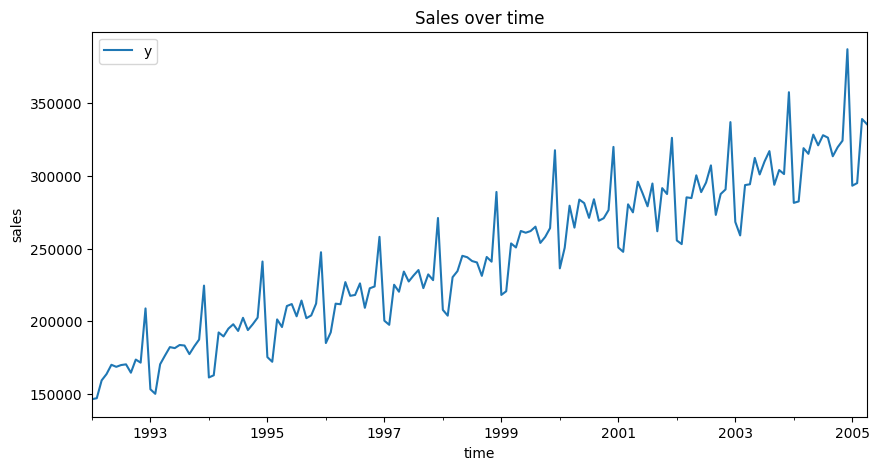

In [5]:
#Plot time series
fig, ax = plt.subplots(figsize=(10, 5))
df.plot(ax=ax)
ax.set_title('Sales over time')
ax.set_xlabel('time')
ax.set_ylabel('sales')
ax.legend(['y'])
plt.show()

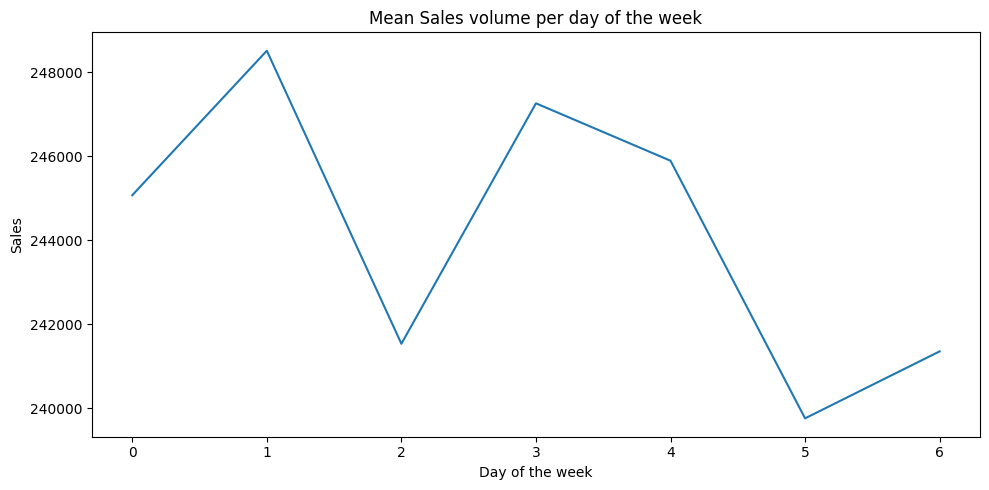

In [11]:
# Seasonality
# 1. define time component like day in this example
# 2. groupby said component and take the mean, define a variable to store the groupby, 
# like in this case group mean.
# 3. plot the new grouped mean.
day = df.index.dayofweek

grouped_mean = df.groupby(day).mean(numeric_only=True)['y']
fig, ax = plt.subplots(figsize=(10, 5))
grouped_mean.plot(ax=ax)
ax.set_xlabel('Day of the week')
ax.set_ylabel('Sales')
ax.set_title('Mean Sales volume per day of the week')
plt.tight_layout()
